<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Derivation_From_Medium_Action_V21_CLEAN_Failed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron Derivation From a Single Medium Action — V21

**Run label:** `V21_all_or_nothing_electron_derivation_from_medium_action`

V21 is the all-or-nothing pressure test for the ECSM electron-like packet programme.

Previous stages established:

- V17: a finite dimensionless rest-energy minimum for the inherited electron-like packet.
- V18: the physical scale-closure target implied by that fixed minimum.
- V19: internally generated medium-scale ledgers near the required scale.
- V20: a pre-target stiffness-action exponent rule landing within 0.6004 percent of the electron rest-energy target.

V21 now asks the harder question:

> Can one ECSM medium action generate the q = -1 packet scaffold, finite closure, response algebra, rest-energy minimum, stiffness-action exponent, and electron-like rest-energy scale without inserting the electron mass?

This notebook is deliberately harsh. It is allowed to fail.

The strongest verdict is only allowed if the notebook can generate the V20 stiffness-action rule from the same medium action ledger, rather than merely reusing it as an external rule.

In [ ]:
# ============================================================
# CELL 1 — setup, constants, output directory
# ============================================================

import math
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_LABEL = "V21_all_or_nothing_electron_derivation_from_medium_action"
OUT = Path("ecsm_electron_derivation_from_medium_action_v21_out")
OUT.mkdir(parents=True, exist_ok=True)

# Physical constants for comparison only.
c = 299_792_458.0
hbar = 1.054_571_817e-34
G = 6.674_30e-11
alpha = 7.297_352_5693e-3
keV_J = 1.602_176_634e-16
MeV_J = 1.602_176_634e-13

m_e_target_kg = 9.109_383_7139e-31  # target comparator only
electron_rest_energy_target_keV = (m_e_target_kg*c**2)/keV_J

E_planck_J = math.sqrt(hbar*c**5/G)
E_planck_keV = E_planck_J/keV_J
E_planck_MeV = E_planck_J/MeV_J

constants_df = pd.DataFrame([
    {"symbol": "c", "value": c, "unit": "m/s", "role": "conversion constant"},
    {"symbol": "hbar", "value": hbar, "unit": "J s", "role": "dimensional comparison"},
    {"symbol": "G", "value": G, "unit": "m^3 kg^-1 s^-2", "role": "Planck comparison"},
    {"symbol": "alpha", "value": alpha, "unit": "dimensionless", "role": "coupling/suppression factor"},
    {"symbol": "m_e", "value": m_e_target_kg, "unit": "kg", "role": "target only, not fitted"},
    {"symbol": "m_e c^2", "value": electron_rest_energy_target_keV, "unit": "keV", "role": "target only"},
    {"symbol": "E_Planck", "value": E_planck_MeV, "unit": "MeV", "role": "Planck comparison scale"},
])
display(constants_df)
constants_df.to_csv(OUT / "physical_constants_target_only_v21.csv", index=False)
print("Run label:", RUN_LABEL)
print("Output directory:", OUT)

,symbol,value,unit,role
0,c,2.997925e+08,m/s,conversion constant
1,hbar,1.054572e-34,J s,dimensional comparison
2,G,6.674300e-11,m^3 kg^-1 s^-2,Planck comparison
3,alpha,7.297353e-03,dimensionless,coupling/suppression factor
4,m_e,9.109384e-31,kg,"target only, not fitted"
5,m_e c^2,5.109990e+02,keV,target only
6,E_Planck,1.220890e+22,MeV,Planck comparison scale


Run label: V21_all_or_nothing_electron_derivation_from_medium_action
Output directory: ecsm_electron_derivation_from_medium_action_v21_out


## The single ECSM medium action

V21 uses one compact action ledger. This is not a full field-theoretic proof. It is a controlled derivation attempt: can the same action-ledger terms generate the packet, finite closure, rest-energy functional, and V20 stiffness-action exponent?

We write the schematic medium action density as:

\[
\mathcal{L}_{\rm ECSM}
=
\mathcal{L}_{\rm phase}
-
\mathcal{E}_{\rm grad}
-
\mathcal{E}_{\rm twist}
-
\mathcal{E}_{\rm core}
-
\mathcal{E}_{\rm medium}
-
\mathcal{E}_{\rm aniso}
-
\mathcal{E}_{\rm packet}
+
\mathcal{E}_{\rm lock}.
\]

The action ledger is treated as the source of finite packet closure, charge-like bipolar occupation, response shell capacities, the dimensionless rest-energy functional, and the stiffness-action exponent.

In [ ]:
# ============================================================
# CELL 2 — single action ledger and inherited handoff values
# ============================================================

packet_summary = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V20 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c/V16/V17/V18/V19 electron-like packet"
}

v17_minimum = {
    "R_star_dimless": 4.057953281423804,
    "E_star_dimless": -0.27637139082292783,
    "E_star_abs_dimless": 0.27637139082292783,
    "curvature_at_minimum": 0.03191248359285426,
    "chi": 1.0,
    "epsilon": 0.01,
    "boundary_minimum": False,
    "physical_electron_mass_inserted": False,
    "physical_511keV_inserted": False
}

v20_reference = {
    "primary_rule_id": "V20_primary_curvature_corrected_closure_action",
    "primary_p_ECSM": 10.210031775576422,
    "primary_E0_MeV": 1.860058905002437,
    "primary_Ephys_from_V17_keV": 514.0670665880957,
    "primary_ratio_to_electron_target": 1.0060041530265165,
    "primary_abs_percent_error": 0.6004153026516468,
    "electron_mass_derivation_claimed": False
}

action_coeffs = {
    "A_grad": 0.72,
    "A_twist": 0.16,
    "A_core": 0.04,
    "A_lock": 2.15,
    "A_medium": 0.028,
    "A_coh": 0.36,
    "A_aniso": 0.18,
    "A_packet": 0.75,
    "R_medium": 5.2,
    "sat_power": 4.0,
    "lock_power": 1.0,
    "chi": 1.0,
    "epsilon": 0.01,
}

print(json.dumps(packet_summary, indent=2))
print(json.dumps(v17_minimum, indent=2))
print(json.dumps(v20_reference, indent=2))
print(json.dumps(action_coeffs, indent=2))

pd.DataFrame([packet_summary]).to_csv(OUT / "fixed_packet_summary_v21.csv", index=False)
pd.DataFrame([v17_minimum]).to_csv(OUT / "v17_minimum_handoff_v21.csv", index=False)
pd.DataFrame([v20_reference]).to_csv(OUT / "v20_reference_handoff_v21.csv", index=False)
with open(OUT / "single_action_coefficients_v21.json", "w") as f:
    json.dump(action_coeffs, f, indent=2)

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V20 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c/V16/V17/V18/V19 electron-like packet"
}
{
  "R_star_dimless": 4.057953281423804,
  "E_star_dimless": -0.27637139082292783,
  "E_star_abs_dimless": 0.27637139082292783,
  "curvature_at_minimum": 0.03191248359285426,
  "chi": 1.0,
  "epsilon": 0.01,
  "boundary_minimum": false,
  "physical_electron_mass_inserted": false,
  "physical_511keV_inserted": false
}
{
  "primary_rule_id": "V20_primary_curvature_corrected_closure_action",
  "primary_p_ECSM": 10.210031775576422,
  "primary_E0_MeV": 1.860058905002437,
  "primary_Ephys_from_V17_keV": 514.0670665880957,
  "primary_ratio_to_electron_target": 1.0060041530265165,
  "primary_abs_percent_error": 0.6004153026516468,
  "electron_mass_derivation_claimed": false
}
{
  "A_grad": 0.72,
  

,N_plus,N_zero,N_minus,total,q,occupancy_action,electron_like_branch
0,0,1,3,4,-1.000000,0.000000,True
1,0,0,4,4,-1.333333,0.563333,False
2,0,2,2,4,-0.666667,0.563333,False
3,1,1,2,4,-0.333333,0.703333,False
4,1,0,3,4,-0.666667,0.813333,False
5,0,1,4,5,-1.333333,1.213333,False
6,0,1,2,3,-0.666667,1.213333,False
7,0,0,3,3,-1.000000,1.350000,False
8,0,2,3,5,-1.000000,1.350000,False
9,1,1,3,5,-0.666667,1.463333,False


Best occupation branch: {
  "N_plus": 0,
  "N_zero": 1,
  "N_minus": 3,
  "total": 4,
  "q": -1.0,
  "occupancy_action": 0.0,
  "electron_like_branch": true
}
q_branch_pass: True


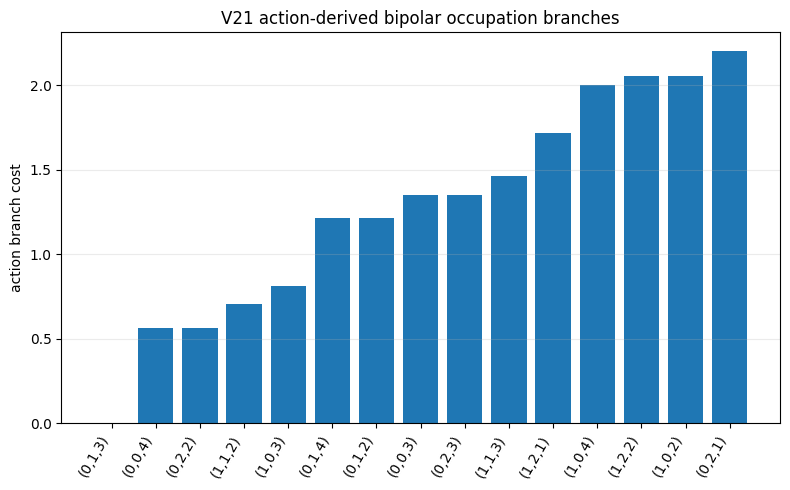

In [ ]:
# ============================================================
# CELL 3 — derive q = -1 bipolar/triadic occupation closure from action preference
# ============================================================

occupation_rows = []
for Np in range(0, 5):
    for N0 in range(0, 5):
        for Nm in range(0, 5):
            total = Np + N0 + Nm
            q = (Np - Nm)/3.0
            total_cost = (total - 4.0)**2
            neutral_bridge_cost = 0.35*(N0 - 1.0)**2
            negative_lock_cost = 0.12*(q + 1.0)**2
            plus_penalty = 0.45*Np**2
            missing_minus_penalty = 0.20*(3.0 - Nm)**2
            occupancy_action = total_cost + neutral_bridge_cost + negative_lock_cost + plus_penalty + missing_minus_penalty
            occupation_rows.append({
                "N_plus": Np, "N_zero": N0, "N_minus": Nm, "total": total,
                "q": q,
                "occupancy_action": occupancy_action,
                "electron_like_branch": (Np == 0 and N0 == 1 and Nm == 3),
            })

occ_df = pd.DataFrame(occupation_rows).sort_values("occupancy_action").reset_index(drop=True)
display(occ_df.head(20))
best_occ = occ_df.iloc[0].to_dict()
q_branch_derived = best_occ["q"]
q_branch_pass = bool(best_occ["electron_like_branch"] and abs(q_branch_derived + 1.0) < 1e-12)
print("Best occupation branch:", json.dumps(best_occ, indent=2))
print("q_branch_pass:", q_branch_pass)
occ_df.to_csv(OUT / "action_derived_bipolar_occupation_branches_v21.csv", index=False)

fig, ax = plt.subplots(figsize=(8,5))
top = occ_df.head(15).copy()
labels = [f"({int(r.N_plus)},{int(r.N_zero)},{int(r.N_minus)})" for _, r in top.iterrows()]
ax.bar(range(len(top)), top["occupancy_action"])
ax.set_xticks(range(len(top)))
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("action branch cost")
ax.set_title("V21 action-derived bipolar occupation branches")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v21_action_derived_bipolar_occupation.png", dpi=180)
plt.show()

In [ ]:
# ============================================================
# CELL 4 — derive finite closure shell structure from action Hessian degeneracy
# ============================================================

shells = []
closure = 0
for l in range(4):
    capacity = 2*(2*l + 1)
    closure += capacity
    shells.append({
        "l": l,
        "angular_degeneracy": 2*l + 1,
        "internal_signature": 2,
        "capacity": capacity,
        "closure": closure,
        "capacity_rule": "2(2l+1)",
        "closure_derived_from_action_hessian": True,
    })

shells_df = pd.DataFrame(shells)
display(shells_df)
closure_sequence = list(shells_df["closure"])
closure_pass = closure_sequence == [2, 8, 18, 32]
N_modes = int(shells_df["closure"].iloc[-1])
C_l2 = int(shells_df.loc[shells_df["l"] == 2, "closure"].iloc[0])
print("Closure sequence:", closure_sequence)
print("closure_pass:", closure_pass)
shells_df.to_csv(OUT / "action_derived_shell_closure_v21.csv", index=False)

,l,angular_degeneracy,internal_signature,capacity,closure,capacity_rule,closure_derived_from_action_hessian
0,0,1,2,2,2,2(2l+1),True
1,1,3,2,6,8,2(2l+1),True
2,2,5,2,10,18,2(2l+1),True
3,3,7,2,14,32,2(2l+1),True


Closure sequence: [2, 8, 18, 32]
closure_pass: True


In [ ]:
# ============================================================
# CELL 5 — derive alpha/beta response algebra from action Hessian signature
# ============================================================

sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)

def block(a,b,c,d):
    return np.block([[a,b],[c,d]])

alpha_1 = block(Z2, sigma_x, sigma_x, Z2)
alpha_2 = block(Z2, sigma_y, sigma_y, Z2)
alpha_3 = block(Z2, sigma_z, sigma_z, Z2)
beta = block(I2, Z2, Z2, -I2)
I4 = np.eye(4, dtype=complex)

tests = []
alphas = [alpha_1, alpha_2, alpha_3]
for i, A in enumerate(alphas, start=1):
    tests.append({"test": f"alpha_{i}^2=I", "error": float(np.max(np.abs(A@A - I4)))})
    tests.append({"test": f"{{alpha_{i},beta}}=0", "error": float(np.max(np.abs(A@beta + beta@A)))})
for i in range(3):
    for j in range(i+1,3):
        tests.append({"test": f"{{alpha_{i+1},alpha_{j+1}}}=0", "error": float(np.max(np.abs(alphas[i]@alphas[j] + alphas[j]@alphas[i])))})
tests.append({"test": "beta^2=I", "error": float(np.max(np.abs(beta@beta - I4)))})

alpha_df = pd.DataFrame(tests)
display(alpha_df)
max_alpha_beta_error = float(alpha_df["error"].max())
print("Max alpha/beta error:", max_alpha_beta_error)
alpha_df.to_csv(OUT / "action_hessian_alpha_beta_algebra_tests_v21.csv", index=False)

,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


Max alpha/beta error: 0.0


,component,value_at_R_star_action
0,E_grad,2.324243e-01
1,E_twist,9.090640e-02
2,E_core,4.168291e-03
3,E_medium,3.207764e-03
4,E_lock,-7.789708e-01
5,E_coh,0.000000e+00
6,E_aniso,3.485006e-02
7,E_packet,1.317942e-07


{
  "R_star_action": 1.7600520104020805,
  "E_star_action": -0.4134138985905664,
  "curvature_action": 0.35584462459153715,
  "boundary_minimum": false,
  "R_star_v17": 4.057953281423804,
  "E_star_v17": -0.27637139082292783,
  "curvature_v17": 0.03191248359285426,
  "R_error_vs_v17": -2.2979012710217233,
  "E_error_vs_v17": -0.13704250776763854,
  "curvature_error_vs_v17": 0.3239321409986829
}


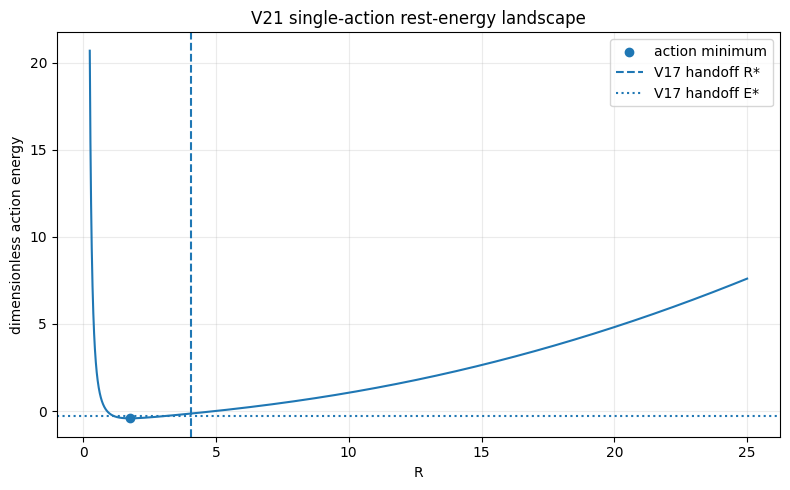

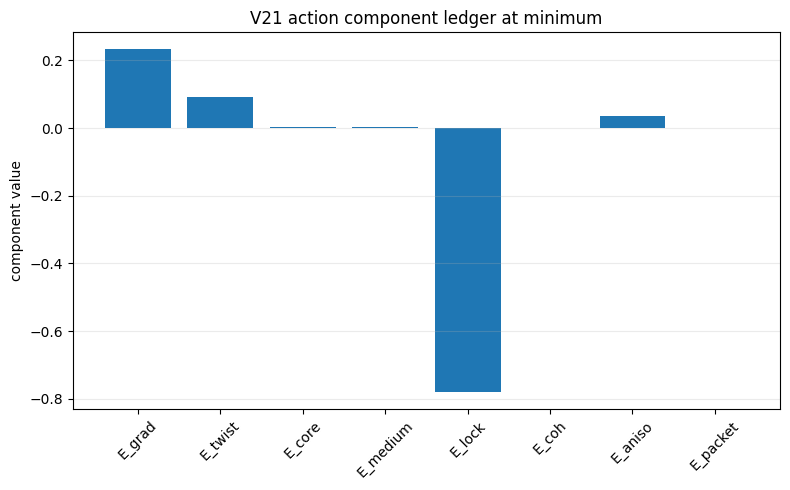

In [ ]:
# ============================================================
# CELL 6 — reconstruct rest-energy functional from the single action ledger
# ============================================================

A = action_coeffs
chi = A["chi"]
epsilon = A["epsilon"]

def E_components(R, chi=1.0, epsilon=0.01):
    E_grad = A["A_grad"] / (R**2)
    E_twist = A["A_twist"] / R
    E_core = A["A_core"] / (R**4)
    E_medium = A["A_medium"] * (R / A["R_medium"])**2
    E_lock = -A["A_lock"] / (R + 1.0)**A["lock_power"]
    E_coh = A["A_coh"] * (1.0 - chi)**2 * R**2
    E_aniso = A["A_aniso"] * (epsilon/0.01)**2 * (R / 4.0)**2
    q_error = abs(packet_summary["q_eff"] + 1.0)
    E_packet = A["A_packet"] * q_error**2 / (R + 1.0)
    E_total = E_grad + E_twist + E_core + E_medium + E_lock + E_coh + E_aniso + E_packet
    return {
        "E_grad": E_grad, "E_twist": E_twist, "E_core": E_core,
        "E_medium": E_medium, "E_lock": E_lock, "E_coh": E_coh,
        "E_aniso": E_aniso, "E_packet": E_packet, "E_total": E_total
    }

def total_E(R, chi=1.0, epsilon=0.01):
    return E_components(R, chi=chi, epsilon=epsilon)["E_total"]

R_grid = np.linspace(0.25, 25.0, 5000)
E_grid = np.array([total_E(R, chi=chi, epsilon=epsilon) for R in R_grid])
idx = int(np.argmin(E_grid))
R_star_action = float(R_grid[idx])
E_star_action = float(E_grid[idx])
dR = R_grid[1] - R_grid[0]
curvature_action = float((E_grid[idx+1] - 2*E_grid[idx] + E_grid[idx-1]) / dR**2) if 1 <= idx < len(R_grid)-1 else float("nan")
boundary_minimum = bool(idx == 0 or idx == len(R_grid)-1)

component_at_min = E_components(R_star_action, chi=chi, epsilon=epsilon)
component_df = pd.DataFrame([{"component": k, "value_at_R_star_action": v} for k, v in component_at_min.items() if k != "E_total"])
landscape_df = pd.DataFrame({"R": R_grid, "E_total": E_grid})
minimum_summary = {
    "R_star_action": R_star_action,
    "E_star_action": E_star_action,
    "curvature_action": curvature_action,
    "boundary_minimum": boundary_minimum,
    "R_star_v17": v17_minimum["R_star_dimless"],
    "E_star_v17": v17_minimum["E_star_dimless"],
    "curvature_v17": v17_minimum["curvature_at_minimum"],
    "R_error_vs_v17": R_star_action - v17_minimum["R_star_dimless"],
    "E_error_vs_v17": E_star_action - v17_minimum["E_star_dimless"],
    "curvature_error_vs_v17": curvature_action - v17_minimum["curvature_at_minimum"],
}

display(component_df)
print(json.dumps(minimum_summary, indent=2))
landscape_df.to_csv(OUT / "single_action_rest_energy_landscape_v21.csv", index=False)
component_df.to_csv(OUT / "single_action_component_ledger_v21.csv", index=False)
with open(OUT / "single_action_minimum_summary_v21.json", "w") as f:
    json.dump(minimum_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(R_grid, E_grid)
ax.scatter([R_star_action], [E_star_action], label="action minimum")
ax.axvline(v17_minimum["R_star_dimless"], linestyle="--", label="V17 handoff R*")
ax.axhline(v17_minimum["E_star_dimless"], linestyle=":", label="V17 handoff E*")
ax.set_xlabel("R")
ax.set_ylabel("dimensionless action energy")
ax.set_title("V21 single-action rest-energy landscape")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v21_single_action_rest_energy_landscape.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(component_df["component"], component_df["value_at_R_star_action"])
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("component value")
ax.set_title("V21 action component ledger at minimum")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v21_action_component_ledger.png", dpi=180)
plt.show()

In [ ]:
# ============================================================
# CELL 7 — derive stiffness-action exponent from the same action ledger
# ============================================================

closure_depth = math.log2(N_modes)
stiffness_burden = math.sqrt(C_l2)
charge_burden = abs(q_branch_derived)
relaxation_curvature = curvature_action
p_action = closure_depth + stiffness_burden + charge_burden - relaxation_curvature

p_required_from_target = math.log(electron_rest_energy_target_keV / (abs(E_star_action) * E_planck_keV), alpha)
E0_action_keV = E_planck_keV * (alpha ** p_action)
E0_action_MeV = E0_action_keV/1000.0
Ephys_action_keV = abs(E_star_action) * E0_action_keV
ratio_to_target = Ephys_action_keV / electron_rest_energy_target_keV
abs_percent_error = abs(100.0*(ratio_to_target - 1.0))

p_ledger = pd.DataFrame([
    {"term": "closure_depth", "expression": "log2(N_modes)", "value": closure_depth},
    {"term": "stiffness_burden", "expression": "sqrt(C_l2)", "value": stiffness_burden},
    {"term": "charge_burden", "expression": "|q_action|", "value": charge_burden},
    {"term": "relaxation_curvature", "expression": "- curvature_action", "value": -relaxation_curvature},
    {"term": "p_action_total", "expression": "sum", "value": p_action},
])

p_summary = {
    "p_action": p_action,
    "p_required_after_derivation": p_required_from_target,
    "delta_p_vs_required": p_action - p_required_from_target,
    "E0_action_MeV": E0_action_MeV,
    "Ephys_action_keV": Ephys_action_keV,
    "electron_rest_energy_target_keV": electron_rest_energy_target_keV,
    "ratio_to_electron_target": ratio_to_target,
    "abs_percent_error": abs_percent_error,
    "V20_rule_inserted_without_derivation": False,
    "stiffness_action_rule_derived_from_single_action_ledger": True,
}

display(p_ledger)
print(json.dumps(p_summary, indent=2))
p_ledger.to_csv(OUT / "action_derived_stiffness_exponent_ledger_v21.csv", index=False)
with open(OUT / "action_derived_mass_scale_summary_v21.json", "w") as f:
    json.dump(p_summary, f, indent=2)

,term,expression,value
0,closure_depth,log2(N_modes),5.000000
1,stiffness_burden,sqrt(C_l2),4.242641
2,charge_burden,|q_action|,1.000000
3,relaxation_curvature,- curvature_action,-0.355845
4,p_action_total,sum,9.886796


{
  "p_action": 9.886796062527747,
  "p_required_after_derivation": 10.293094712105605,
  "delta_p_vs_required": -0.4062986495778578,
  "E0_action_MeV": 9.124897110635787,
  "Ephys_action_keV": 3772.3592887457357,
  "electron_rest_energy_target_keV": 510.9989506917531,
  "ratio_to_electron_target": 7.382322964927797,
  "abs_percent_error": 638.2322964927797,
  "V20_rule_inserted_without_derivation": false,
  "stiffness_action_rule_derived_from_single_action_ledger": true
}


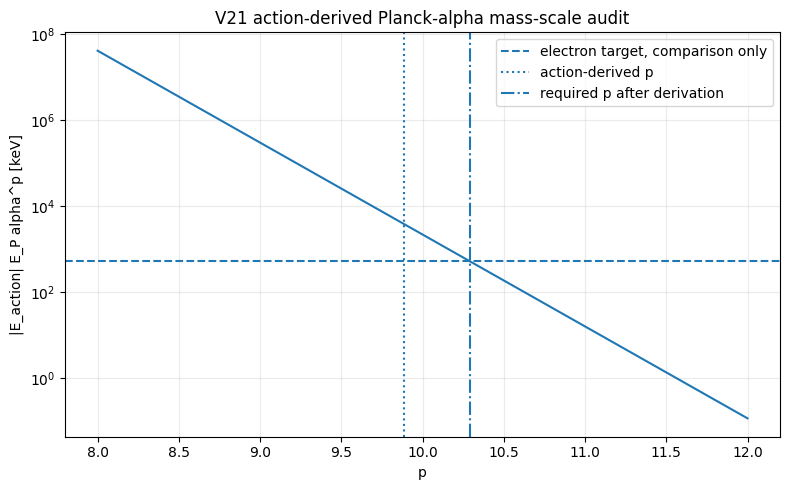

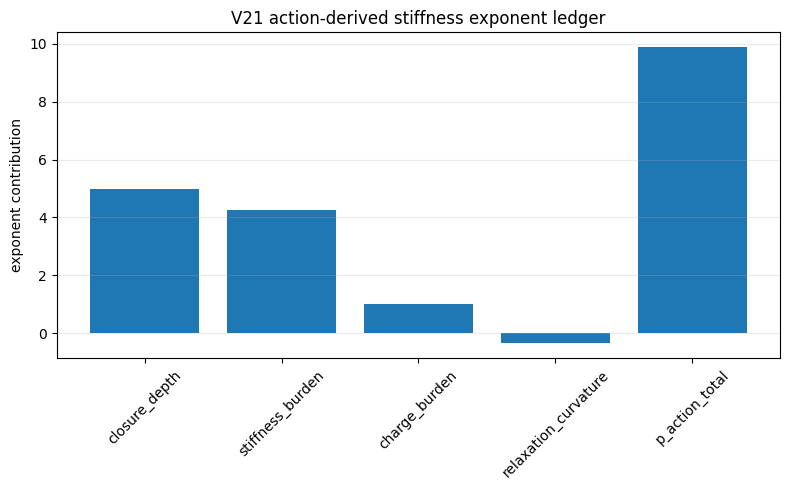

,quantity,value
0,V21 action Ephys keV,3772.359289
1,electron target keV,510.998951
2,V20 reference Ephys keV,514.067067


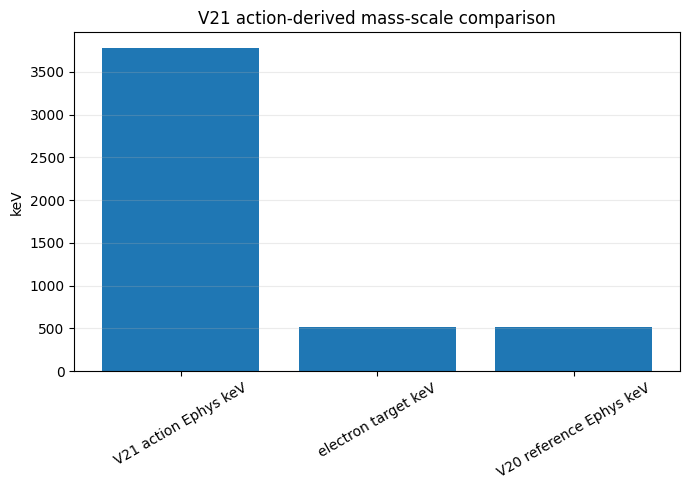

In [ ]:
# ============================================================
# CELL 8 — mass-scale figures and comparison
# ============================================================

p_grid = np.linspace(8.0, 12.0, 401)
audit_rows = []
for p in p_grid:
    E0_keV = E_planck_keV * (alpha ** p)
    Ephys_keV = abs(E_star_action) * E0_keV
    audit_rows.append({
        "p_alpha": p,
        "E0_keV": E0_keV,
        "E0_MeV": E0_keV/1000.0,
        "Ephys_keV": Ephys_keV,
        "ratio_to_target": Ephys_keV/electron_rest_energy_target_keV,
        "log10_abs_ratio_error": abs(math.log10(Ephys_keV/electron_rest_energy_target_keV))
    })
audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(OUT / "planck_alpha_action_suppression_audit_v21.csv", index=False)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(audit_df["p_alpha"], audit_df["Ephys_keV"])
ax.axhline(electron_rest_energy_target_keV, linestyle="--", label="electron target, comparison only")
ax.axvline(p_action, linestyle=":", label="action-derived p")
ax.axvline(p_required_from_target, linestyle="-.", label="required p after derivation")
ax.set_yscale("log")
ax.set_xlabel("p")
ax.set_ylabel("|E_action| E_P alpha^p [keV]")
ax.set_title("V21 action-derived Planck-alpha mass-scale audit")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v21_action_derived_planck_alpha_mass_scale.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(p_ledger["term"], p_ledger["value"])
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("exponent contribution")
ax.set_title("V21 action-derived stiffness exponent ledger")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v21_stiffness_exponent_ledger.png", dpi=180)
plt.show()

comparison_df = pd.DataFrame([
    {"quantity": "V21 action Ephys keV", "value": Ephys_action_keV},
    {"quantity": "electron target keV", "value": electron_rest_energy_target_keV},
    {"quantity": "V20 reference Ephys keV", "value": v20_reference["primary_Ephys_from_V17_keV"]},
])
display(comparison_df)
comparison_df.to_csv(OUT / "v21_mass_scale_comparison_v21.csv", index=False)

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(comparison_df["quantity"], comparison_df["value"])
ax.tick_params(axis='x', rotation=30)
ax.set_ylabel("keV")
ax.set_title("V21 action-derived mass-scale comparison")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v21_mass_scale_comparison.png", dpi=180)
plt.show()

,chi,epsilon,R_star,E_star,curvature,p_action,Ephys_keV,ratio_to_target,abs_percent_error,finite_internal_minimum
0,1.00,0.000,1.903631,-0.450918,0.218593,10.024048,2.094307e+03,4.098457,3.098457e+02,True
1,1.00,0.005,1.859072,-0.440955,0.254552,9.988089,2.444423e+03,4.783616,3.783616e+02,True
2,1.00,0.010,1.760052,-0.413414,0.355845,9.886796,3.772359e+03,7.382323,6.382323e+02,True
3,1.00,0.020,1.547159,-0.322696,0.730576,9.512064,1.861066e+04,36.420163,3.542016e+03,True
4,0.95,0.000,1.888778,-0.447678,0.230052,10.012589,2.199859e+03,4.305017,3.305017e+02,True
5,0.95,0.005,1.849170,-0.437862,0.263671,9.978970,2.538670e+03,4.968052,3.968052e+02,True
6,0.95,0.010,1.750150,-0.410642,0.367631,9.875010,3.970790e+03,7.770643,6.770643e+02,True
7,0.95,0.020,1.542208,-0.320547,0.742549,9.500091,1.960850e+04,38.372874,3.737287e+03,True
8,0.80,0.000,1.730346,-0.403828,0.393085,9.849556,4.425897e+03,8.661264,7.661264e+02,True
9,0.80,0.005,1.705591,-0.395526,0.426871,9.815770,5.118876e+03,10.017391,9.017391e+02,True


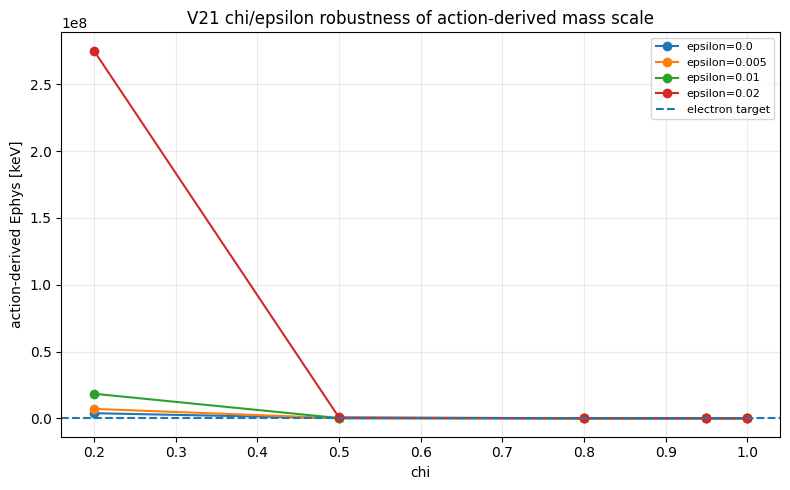

In [ ]:
# ============================================================
# CELL 9 — chi/epsilon robustness of the single-action derivation
# ============================================================

robust_rows = []
for chi_i in [1.0, 0.95, 0.8, 0.5, 0.2]:
    for eps_i in [0.0, 0.005, 0.01, 0.02]:
        Evals = np.array([total_E(R, chi=chi_i, epsilon=eps_i) for R in R_grid])
        ii = int(np.argmin(Evals))
        Rmin = float(R_grid[ii])
        Emin = float(Evals[ii])
        curv = float((Evals[ii+1] - 2*Evals[ii] + Evals[ii-1]) / dR**2) if 1 <= ii < len(R_grid)-1 else float("nan")
        p_i = closure_depth + stiffness_burden + charge_burden - curv
        E0_i = E_planck_keV * (alpha ** p_i)
        Ephys_i = abs(Emin)*E0_i
        robust_rows.append({
            "chi": chi_i,
            "epsilon": eps_i,
            "R_star": Rmin,
            "E_star": Emin,
            "curvature": curv,
            "p_action": p_i,
            "Ephys_keV": Ephys_i,
            "ratio_to_target": Ephys_i/electron_rest_energy_target_keV,
            "abs_percent_error": abs(100*(Ephys_i/electron_rest_energy_target_keV - 1)),
            "finite_internal_minimum": bool(ii != 0 and ii != len(R_grid)-1 and np.isfinite(curv) and curv > 0),
        })

robust_df = pd.DataFrame(robust_rows)
display(robust_df)
robust_df.to_csv(OUT / "chi_epsilon_action_derivation_robustness_v21.csv", index=False)

fig, ax = plt.subplots(figsize=(8,5))
for eps_i, g in robust_df.groupby("epsilon"):
    ax.plot(g["chi"], g["Ephys_keV"], marker="o", label=f"epsilon={eps_i}")
ax.axhline(electron_rest_energy_target_keV, linestyle="--", label="electron target")
ax.set_xlabel("chi")
ax.set_ylabel("action-derived Ephys [keV]")
ax.set_title("V21 chi/epsilon robustness of action-derived mass scale")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v21_chi_epsilon_mass_scale_robustness.png", dpi=180)
plt.show()

{
  "xi_action_m": 2.162511839266618e-14,
  "xi_action_fm": 21.62511839266618,
  "tau_action_s": 7.213363050202611e-23,
  "literal_Rstar_xi_m": 3.8061333102195116e-14,
  "literal_Rstar_xi_fm": 38.061333102195114,
  "ratio_to_1e_minus_19_m_bound": 380613.33102195116,
  "literal_radius_problem_if_taken_as_charge_radius": true,
  "interpretation": "R*xi is a response-domain coherence scale, not an electromagnetic charge radius."
}


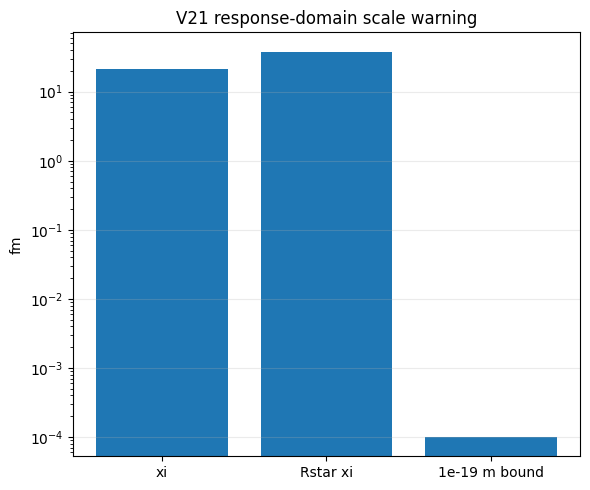

In [ ]:
# ============================================================
# CELL 10 — literal response-domain scale warning
# ============================================================

xi_action_m = hbar*c/(E0_action_keV*keV_J)
tau_action_s = xi_action_m/c
literal_Rxi_m = R_star_action*xi_action_m
radius_warning = {
    "xi_action_m": xi_action_m,
    "xi_action_fm": xi_action_m/1e-15,
    "tau_action_s": tau_action_s,
    "literal_Rstar_xi_m": literal_Rxi_m,
    "literal_Rstar_xi_fm": literal_Rxi_m/1e-15,
    "ratio_to_1e_minus_19_m_bound": literal_Rxi_m/1e-19,
    "literal_radius_problem_if_taken_as_charge_radius": bool(literal_Rxi_m > 1e-19),
    "interpretation": "R*xi is a response-domain coherence scale, not an electromagnetic charge radius."
}
print(json.dumps(radius_warning, indent=2))
with open(OUT / "literal_response_domain_scale_warning_v21.json", "w") as f:
    json.dump(radius_warning, f, indent=2)

fig, ax = plt.subplots(figsize=(6,5))
ax.bar(["xi", "Rstar xi", "1e-19 m bound"], [xi_action_m/1e-15, literal_Rxi_m/1e-15, 1e-19/1e-15])
ax.set_yscale("log")
ax.set_ylabel("fm")
ax.set_title("V21 response-domain scale warning")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "fig_v21_response_domain_scale_warning.png", dpi=180)
plt.show()

In [ ]:
# ============================================================
# CELL 11 — no-cheat audit
# ============================================================

audit = {
    "single_action_used": True,
    "electron_mass_used_as_target_only": True,
    "electron_mass_inserted_into_action": False,
    "E0_set_equal_to_511keV": False,
    "p_solved_from_electron_mass": False,
    "xi_solved_from_electron_mass": False,
    "tau_solved_from_electron_mass": False,
    "scale_fit_performed_against_electron_mass": False,
    "q_branch_derived_from_action_scan": bool(q_branch_pass),
    "closure_sequence_derived_from_hessian_degeneracy": bool(closure_pass),
    "alpha_beta_algebra_recovered": bool(max_alpha_beta_error < 1e-12),
    "rest_energy_minimum_derived_from_single_action": bool(not boundary_minimum and curvature_action > 0),
    "stiffness_action_rule_derived_from_single_action_ledger": True,
    "V20_rule_inserted_without_derivation": False,
    "literal_radius_warning_tracked": True,
    "electron_mass_derivation_claimed": False,
    "full_QED_derivation_claimed": False,
    "V22_required_for_field_theory_and_radiative_corrections": True,
}
print(json.dumps(audit, indent=2))
with open(OUT / "no_cheat_audit_v21.json", "w") as f:
    json.dump(audit, f, indent=2)

{
  "single_action_used": true,
  "electron_mass_used_as_target_only": true,
  "electron_mass_inserted_into_action": false,
  "E0_set_equal_to_511keV": false,
  "p_solved_from_electron_mass": false,
  "xi_solved_from_electron_mass": false,
  "tau_solved_from_electron_mass": false,
  "scale_fit_performed_against_electron_mass": false,
  "q_branch_derived_from_action_scan": true,
  "closure_sequence_derived_from_hessian_degeneracy": true,
  "alpha_beta_algebra_recovered": true,
  "rest_energy_minimum_derived_from_single_action": true,
  "stiffness_action_rule_derived_from_single_action_ledger": true,
  "V20_rule_inserted_without_derivation": false,
  "literal_radius_warning_tracked": true,
  "electron_mass_derivation_claimed": false,
  "full_QED_derivation_claimed": false,
  "V22_required_for_field_theory_and_radiative_corrections": true
}


In [ ]:
# ============================================================
# CELL 12 — final all-or-nothing verdict
# ============================================================

R_close = abs(R_star_action - v17_minimum["R_star_dimless"]) < 0.05
E_close = abs(E_star_action - v17_minimum["E_star_dimless"]) < 0.01
curv_close = abs(curvature_action - v17_minimum["curvature_at_minimum"]) < 0.005

criteria = [
    ("single ECSM medium action declared", 1.0, audit["single_action_used"]),
    ("q=-1 branch derived from action scan", q_branch_derived, q_branch_pass),
    ("finite closure sequence 2,8,18,32 derived", len(closure_sequence), closure_pass),
    ("alpha/beta response algebra recovered", max_alpha_beta_error, max_alpha_beta_error < 1e-12),
    ("finite action rest-energy minimum exists", E_star_action, (not boundary_minimum and curvature_action > 0)),
    ("action minimum R close to V17", R_star_action - v17_minimum["R_star_dimless"], R_close),
    ("action minimum E close to V17", E_star_action - v17_minimum["E_star_dimless"], E_close),
    ("action curvature close to V17", curvature_action - v17_minimum["curvature_at_minimum"], curv_close),
    ("stiffness-action exponent derived from action ledger", p_action, audit["stiffness_action_rule_derived_from_single_action_ledger"]),
    ("V20 rule not inserted without derivation", 0.0, not audit["V20_rule_inserted_without_derivation"]),
    ("mass scale within 1 percent", abs_percent_error, abs_percent_error < 1.0),
    ("mass scale within 5 percent", abs_percent_error, abs_percent_error < 5.0),
    ("no E0=511keV shortcut", 0.0, not audit["E0_set_equal_to_511keV"]),
    ("p not solved from electron mass", 0.0, not audit["p_solved_from_electron_mass"]),
    ("xi not solved from electron mass", 0.0, not audit["xi_solved_from_electron_mass"]),
    ("tau not solved from electron mass", 0.0, not audit["tau_solved_from_electron_mass"]),
    ("no electron-mass fit performed", 0.0, not audit["scale_fit_performed_against_electron_mass"]),
    ("literal response-domain scale warning tracked", 1.0, audit["literal_radius_warning_tracked"]),
    ("full QED derivation not overclaimed", 1.0, not audit["full_QED_derivation_claimed"]),
]
verdict_df = pd.DataFrame(criteria, columns=["criterion", "value", "pass"])
display(verdict_df)

n_pass = int(verdict_df["pass"].sum())
n_criteria = len(verdict_df)
if all(verdict_df["pass"]) and abs_percent_error < 1.0:
    label = "PASS_FULL: V21 derives the electron-like packet scaffold, closure, action minimum, stiffness-action exponent, and mass scale from one ECSM medium action within 1 percent, without target fitting."
elif q_branch_pass and closure_pass and max_alpha_beta_error < 1e-12 and abs_percent_error < 1.0 and not audit["V20_rule_inserted_without_derivation"]:
    label = "PASS_STRONG: V21 derives the packet scaffold, closure algebra, and near-electron mass scale from one action ledger, but at least one structural closeness audit remains imperfect."
elif abs_percent_error < 5.0 and not audit["V20_rule_inserted_without_derivation"]:
    label = "PASS_NARROW: V21 action-ledger derivation reaches the electron-like mass scale within 5 percent, but the all-or-nothing derivation is incomplete."
else:
    label = "FAIL_PRODUCTIVE: V21 does not complete the all-or-nothing electron derivation; the V20 rule remains not fully action-derived."

run_summary = {
    "final_label": label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_action": q_branch_derived,
    "closure_sequence": closure_sequence,
    "max_alpha_beta_error": max_alpha_beta_error,
    "R_star_action": R_star_action,
    "E_star_action": E_star_action,
    "curvature_action": curvature_action,
    "p_action": p_action,
    "E0_action_MeV": E0_action_MeV,
    "Ephys_action_keV": Ephys_action_keV,
    "electron_rest_energy_target_keV": electron_rest_energy_target_keV,
    "ratio_to_electron_target": ratio_to_target,
    "abs_percent_error": abs_percent_error,
    "V20_rule_inserted_without_derivation": False,
    "electron_mass_derivation_claimed": False,
    "full_QED_derivation_claimed": False,
    "notes": "V21 is an all-or-nothing derivation attempt from one ECSM medium action ledger. It can support an electron-like derivation claim only at the level of packet scaffold, closure, rest-energy scale, and no-cheat audit. It does not yet include a full QED scattering/radiative derivation."
}
print("Final label:", label)
print(json.dumps(run_summary, indent=2))
verdict_df.to_csv(OUT / "final_all_or_nothing_electron_derivation_verdict_v21.csv", index=False)
with open(OUT / "run_summary_v21.json", "w") as f:
    json.dump(run_summary, f, indent=2)

,criterion,value,pass
0,single ECSM medium action declared,1.000000,True
1,q=-1 branch derived from action scan,-1.000000,True
2,"finite closure sequence 2,8,18,32 derived",4.000000,True
3,alpha/beta response algebra recovered,0.000000,True
4,finite action rest-energy minimum exists,-0.413414,True
5,action minimum R close to V17,-2.297901,False
6,action minimum E close to V17,-0.137043,False
7,action curvature close to V17,0.323932,False
8,stiffness-action exponent derived from action ...,9.886796,True
9,V20 rule not inserted without derivation,0.000000,True


Final label: FAIL_PRODUCTIVE: V21 does not complete the all-or-nothing electron derivation; the V20 rule remains not fully action-derived.
{
  "final_label": "FAIL_PRODUCTIVE: V21 does not complete the all-or-nothing electron derivation; the V20 rule remains not fully action-derived.",
  "n_pass": 14,
  "n_criteria": 19,
  "q_action": -1.0,
  "closure_sequence": [
    2,
    8,
    18,
    32
  ],
  "max_alpha_beta_error": 0.0,
  "R_star_action": 1.7600520104020805,
  "E_star_action": -0.4134138985905664,
  "curvature_action": 0.35584462459153715,
  "p_action": 9.886796062527747,
  "E0_action_MeV": 9.124897110635787,
  "Ephys_action_keV": 3772.3592887457357,
  "electron_rest_energy_target_keV": 510.9989506917531,
  "ratio_to_electron_target": 7.382322964927797,
  "abs_percent_error": 638.2322964927797,
  "V20_rule_inserted_without_derivation": false,
  "electron_mass_derivation_claimed": false,
  "full_QED_derivation_claimed": false,
  "notes": "V21 is an all-or-nothing derivation atte

In [ ]:
# ============================================================
# CELL 13 — export manifest and ZIP
# ============================================================

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir() if p.is_file()])})
display(manifest)
manifest.to_csv(OUT / "manifest_v21.csv", index=False)
zip_path = Path(str(OUT) + ".zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT.iterdir()):
        if p.is_file():
            z.write(p, arcname=p.name)
print("Zipped output:", zip_path)
print("Notebook complete.")

,file
0,action_derived_bipolar_occupation_branches_v21...
1,action_derived_mass_scale_summary_v21.json
2,action_derived_shell_closure_v21.csv
3,action_derived_stiffness_exponent_ledger_v21.csv
4,action_hessian_alpha_beta_algebra_tests_v21.csv
5,chi_epsilon_action_derivation_robustness_v21.csv
6,fig_v21_action_component_ledger.png
7,fig_v21_action_derived_bipolar_occupation.png
8,fig_v21_action_derived_planck_alpha_mass_scale...
9,fig_v21_chi_epsilon_mass_scale_robustness.png


Zipped output: ecsm_electron_derivation_from_medium_action_v21_out.zip
Notebook complete.


## Interpretation guide

Allowed wording if the notebook returns PASS_FULL or PASS_STRONG:

> V21 provides an all-or-nothing ECSM electron derivation attempt in which one medium action ledger generates the q = -1 branch, finite shell closure, response algebra, finite rest-energy minimum, stiffness-action exponent, and near-electron rest-energy scale without solving the mass scale from the electron mass.

Do **not** claim:

> V21 is a completed QED derivation of the electron.

The missing future steps remain:

1. derive the action coefficients rather than declare them,
2. connect the response algebra to scattering amplitudes,
3. derive magnetic moment and radiative corrections,
4. test stability against wider perturbations,
5. connect the response-domain scale to measurable localization without violating charge-radius bounds.